In [28]:
!pip install reject

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import seaborn as sns
import random
import glob
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import  ImageDataGenerator
from keras.layers import Dense,Flatten
from keras.callbacks import EarlyStopping,ModelCheckpoint
from keras import Model
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report , confusion_matrix

In [30]:
positive = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/pCT/*.jpg')
nigative = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/nCT/*.jpg')


random.shuffle(positive)
random.shuffle(nigative)

train_positive = positive [:int (len (positive) *0.8)]
test_positive = positive[int (len (positive) *0.8):]

train_nigative =nigative [:int (len (nigative) *0.8)]
test_nigative = nigative[int (len (nigative) *0.8):]

print ('number of train positive CT = {}'.format(len (train_positive)))
print ('number of train nigative CT = {}'.format(len (train_nigative)))

print ('------------------------------------')

print ('number of test positive CT = {}'.format(len (test_positive)))
print ('number of test nigative CT = {}'.format(len (test_nigative)))

number of train positive CT = 3200
number of train nigative CT = 7983
------------------------------------
number of test positive CT = 801
number of test nigative CT = 1996


In [31]:
def convert_links_to_images(data):
    images =[]
    for image in data:
        img = cv2.resize(cv2.imread(image), (256, 256) )
        images.append(img)
    return np.array (images)

In [32]:
train_positive_images = convert_links_to_images(train_positive)
train_negative_images = convert_links_to_images(train_nigative)
test_positive_images = convert_links_to_images(test_positive)
test_negative_images = convert_links_to_images(test_nigative)  


In [33]:
# Chỉ sử dụng dữ liệu từ hai lớp: positive và negative
y_train = np.concatenate([np.zeros(len(train_positive_images)), np.ones(len(train_negative_images))])
y_train = keras.utils.to_categorical(y_train, num_classes=2)  # Chỉ 2 lớp
X_train = np.concatenate([train_positive_images, train_negative_images], axis=0)

y_test = np.concatenate([np.zeros(len(test_positive_images)), np.ones(len(test_negative_images))])
y_test = keras.utils.to_categorical(y_test, num_classes=2)  # Chỉ 2 lớp
X_test = np.concatenate([test_positive_images, test_negative_images], axis=0)

# In kích thước dữ liệu
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Giải phóng bộ nhớ
train_positive_images, train_negative_images, test_positive_images, test_negative_images = None, None, None, None
del train_positive_images, train_negative_images, test_positive_images, test_negative_images

(11183, 256, 256, 3)
(11183, 2)
(2797, 256, 256, 3)
(2797, 2)


In [34]:
train_datagen = ImageDataGenerator( rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True,
                                    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255,)

train_generator = train_datagen.flow(X_train, y_train,batch_size=16,shuffle=True)
test_generator = test_datagen.flow(X_test, y_test,batch_size=16,shuffle=False)
#--------------------------------free some memory--------------------------------

In [35]:
model = load_model('/kaggle/input/unagument_model/keras/default/1/CT_COVID_Res32_2label_unagument.keras')

In [36]:
import numpy as np
import torch
import pdb

def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions for the specified values of k"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        
        res = []
#         for k in topk:
#             correct_k = correct[:k].view(-1).float().sum(0, keepdim=True)
#             res.append(correct_k.mul_(100.0 / batch_size).numpy())
        
        correct_k = correct[:1].view(-1).float().sum(0, keepdim=True)
        
        res = correct_k.mul_(100.0 / batch_size).cpu().numpy()

        return res


def calibration(true_labels, pred_labels, confidences, num_bins=15):
    """Collects predictions into bins used to draw a reliability diagram.

    Arguments:
        true_labels: the true labels for the test examples
        pred_labels: the predicted labels for the test examples
        confidences: the predicted confidences for the test examples
        num_bins: number of bins

    The true_labels, pred_labels, confidences arguments must be NumPy arrays;
    pred_labels and true_labels may contain numeric or string labels.

    For a multi-class model, the predicted label and confidence should be those
    of the highest scoring class.

    Returns a dictionary containing the following NumPy arrays:
        accuracies: the average accuracy for each bin
        confidences: the average confidence for each bin
        counts: the number of examples in each bin
        bins: the confidence thresholds for each bin
        avg_accuracy: the accuracy over the entire test set
        avg_confidence: the average confidence over the entire test set
        expected_calibration_error: a weighted average of all calibration gaps
        max_calibration_error: the largest calibration gap across all bins
    """
    assert(len(confidences) == len(pred_labels))
    assert(len(confidences) == len(true_labels))
    assert(num_bins > 0)

    bin_size = 1.0 / num_bins
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    indices = np.digitize(confidences, bins, right=True)

    bin_accuracies = np.zeros(num_bins, dtype=np.float64)
    bin_confidences = np.zeros(num_bins, dtype=np.float64)
    bin_counts = np.zeros(num_bins, dtype=np.int64)

    for b in range(num_bins):
        selected = np.where(indices == b + 1)[0]
        if len(selected) > 0:
            bin_accuracies[b] = np.mean(true_labels[selected] == pred_labels[selected])
            bin_confidences[b] = np.mean(confidences[selected])
            bin_counts[b] = len(selected)

    avg_acc = np.sum(bin_accuracies * bin_counts) / np.sum(bin_counts)
    avg_conf = np.sum(bin_confidences * bin_counts) / np.sum(bin_counts)

    gaps = np.abs(bin_accuracies - bin_confidences)
    ece = np.sum(gaps * bin_counts) / np.sum(bin_counts)
    mce = np.max(gaps)

    return { "accuracies": bin_accuracies, 
             "confidences": bin_confidences, 
             "counts": bin_counts, 
             "bins": bins,
             "avg_accuracy": avg_acc,
             "avg_confidence": avg_conf,
             "expected_calibration_error": ece,
             "max_calibration_error": mce }

In [37]:
y_pred = model.predict(X_test)
pred_labels = np.argmax(y_pred, axis=1)
confidences = np.max(y_pred, axis=1)

true_labels = np.argmax(y_test, axis=1)

calibration_results = calibration(true_labels, pred_labels, confidences, num_bins=15)

print("Expected Calibration Error (ECE):", calibration_results["expected_calibration_error"])
print("Max Calibration Error (MCE):", calibration_results["max_calibration_error"])

88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step
Expected Calibration Error (ECE): 0.25598855917053986
Max Calibration Error (MCE): 0.25598855917053986


In [38]:
from tensorflow.keras.layers import Multiply

def add_lws_layer(model):
    logits = model.output
    
    lws_weights = Dense(2, use_bias=False, kernel_initializer='ones', name='lws_weights')(logits)
    scaled_logits = Multiply()([logits, lws_weights])
    
    new_model = Model(inputs=model.input, outputs=scaled_logits)
    return new_model

# Thêm LWS vào mô hình
model_with_lws = add_lws_layer(model)
# model_with_lws.summary()

In [39]:
import numpy as np
import tensorflow as tf

def find_optimal_temperature(model, val_generator, y_true):

    # Lấy logits từ mô hình
    val_logits = model.predict(val_generator)
    
    # Chuyển đổi y_true sang dạng số nguyên nếu nó là one-hot encoding
    if y_true.ndim > 1:  # Nếu y_true là one-hot encoding
        y_true = np.argmax(y_true, axis=1)
    
    # Tìm giá trị T tối ưu
    best_T = 1.0  # Giá trị mặc định
    best_ece = float('inf')  # ECE tốt nhất ban đầu là vô cùng
    
    # Duyệt qua các giá trị T trong khoảng [0.1, 10.0]
    for T in np.linspace(0.1, 10.0, 100):
        # Điều chỉnh logits bằng nhiệt độ T
        scaled_logits = val_logits / T
        
        # Tính xác suất từ logits đã điều chỉnh
        scaled_probs = tf.nn.softmax(scaled_logits, axis=1).numpy()
        
        # Lấy nhãn dự đoán và độ tin cậy
        pred_labels = np.argmax(scaled_probs, axis=1)
        confidences = np.max(scaled_probs, axis=1)
        
        # Tính ECE bằng hàm calibration
        calibration_result = calibration(y_true, pred_labels, confidences)
        ece = calibration_result["expected_calibration_error"]
        
        # Cập nhật T tối ưu nếu ECE tốt hơn
        if ece < best_ece:
            best_ece = ece
            best_T = T
    
    return best_T

# Tìm giá trị T tối ưu trên tập validation
optimal_T = find_optimal_temperature(model_with_lws, test_generator, y_test)
print(f"Optimal Temperature: {optimal_T}")

175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step
Optimal Temperature: 0.2


In [40]:
def apply_temperature_scaling(model, test_generator, y_true, T):
    # Lấy logits từ mô hình
    test_logits = model.predict(test_generator)
    
    # Chuyển đổi y_true sang dạng số nguyên nếu nó là one-hot encoding
    if y_true.ndim > 1:  # Nếu y_true là one-hot encoding
        y_true = np.argmax(y_true, axis=1)
    
    # Áp dụng Temperature Scaling
    scaled_logits = test_logits / T
    scaled_probs = tf.nn.softmax(scaled_logits, axis=1).numpy()
    confidences = np.max(scaled_probs, axis=1)
    pred_labels = np.argmax(scaled_probs, axis=1)
    
    # Tính toán ECE và MCE
    calibration_results = calibration(y_true, pred_labels, confidences)
    print("Expected Calibration Error (ECE):", calibration_results["expected_calibration_error"])
    print("Max Calibration Error (MCE):", calibration_results["max_calibration_error"])
    
    return scaled_probs, pred_labels, confidences
apply_temperature_scaling(model_with_lws, test_generator, y_test, optimal_T)
    

175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step
Expected Calibration Error (ECE): 0.003790986294997029
Max Calibration Error (MCE): 0.5143409967422485


(array([[0.9933072 , 0.00669285],
        [0.9933072 , 0.00669287],
        [0.9933072 , 0.00669289],
        ...,
        [0.00669286, 0.9933072 ],
        [0.00669285, 0.9933072 ],
        [0.00669285, 0.9933072 ]], dtype=float32),
 array([0, 0, 0, ..., 1, 1, 1]),
 array([0.9933072, 0.9933072, 0.9933072, ..., 0.9933072, 0.9933072,
        0.9933072], dtype=float32))

175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       801
           1       1.00      0.99      1.00      1996

    accuracy                           0.99      2797
   macro avg       0.99      0.99      0.99      2797
weighted avg       0.99      0.99      0.99      2797



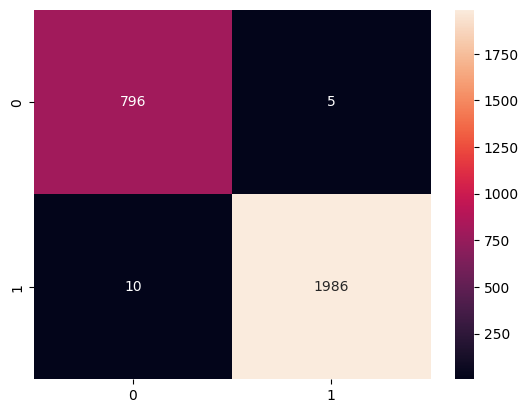

In [41]:
y_pred = np.round (model_with_lws.predict (test_generator))
y_pred = np.argmax (y_pred,axis =1)
y_test = np.argmax (y_test,axis =1)
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt='d')
print (classification_report (y_test,y_pred))

88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step
Area Under the RC Curve (AURC): 0.005362888809438693


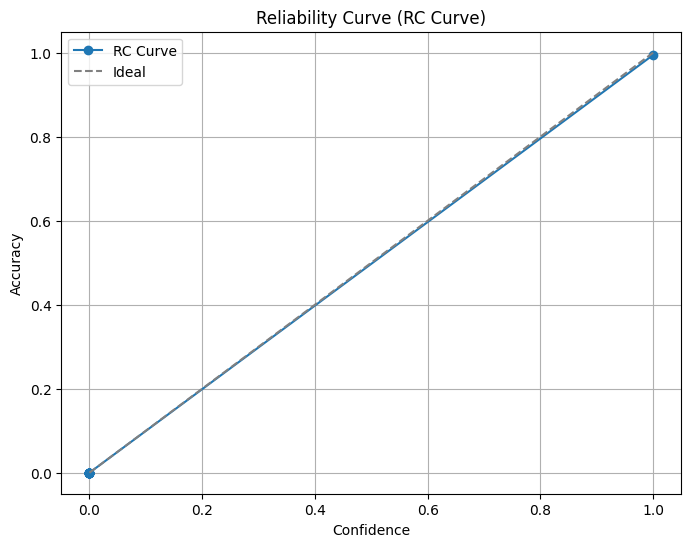

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def compute_rc_curve(true_labels, pred_labels, confidences, num_bins=15):
    """
    Compute the Reliability Curve (RC Curve) and Area Under the RC Curve (AURC).

    Args:
        true_labels: True labels of the data.
        pred_labels: Predicted labels by the model.
        confidences: Confidence scores of the predictions.
        num_bins: Number of bins to divide the confidence scores.

    Returns:
        rc_curve: A dictionary containing the RC Curve data.
        aurc: Area Under the RC Curve.
    """
    bin_size = 1.0 / num_bins
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    indices = np.digitize(confidences, bins, right=True)

    bin_accuracies = np.zeros(num_bins, dtype=np.float64)
    bin_confidences = np.zeros(num_bins, dtype=np.float64)
    bin_counts = np.zeros(num_bins, dtype=np.int64)

    for b in range(num_bins):
        selected = np.where(indices == b + 1)[0]
        if len(selected) > 0:
            bin_accuracies[b] = accuracy_score(true_labels[selected], pred_labels[selected])
            bin_confidences[b] = np.mean(confidences[selected])
            bin_counts[b] = len(selected)

    # Compute AURC
    aurc = np.sum(np.abs(bin_accuracies - bin_confidences) * bin_counts) / np.sum(bin_counts)

    rc_curve = {
        "accuracies": bin_accuracies,
        "confidences": bin_confidences,
        "counts": bin_counts,
        "bins": bins,
        "aurc": aurc
    }

    return rc_curve, aurc

def plot_rc_curve(rc_curve):
    """
    Plot the Reliability Curve (RC Curve).

    Args:
        rc_curve: A dictionary containing the RC Curve data.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(rc_curve["confidences"], rc_curve["accuracies"], marker='o', label='RC Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Reliability Curve (RC Curve)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
y_pred_probs = model_with_lws.predict(X_test)
confidences = np.max(y_pred_probs, axis=1)

rc_curve, aurc = compute_rc_curve(y_test, y_pred, confidences)
print(f"Area Under the RC Curve (AURC): {aurc}")
plot_rc_curve(rc_curve)

In [43]:
from sklearn.metrics import brier_score_loss

def compute_brier_score(y_true, y_prob):
    
    return brier_score_loss(y_true, y_prob)

brier_score = compute_brier_score(true_labels, confidences)
print(f"Brier Score: {brier_score}")


Brier Score: 0.28637826225668295


In [44]:
import reject
from reject.reject import ClassificationRejector
from reject.utils import generate_synthetic_output

In [45]:
print(reject.__version__)

0.3.2


In [46]:
y_pred = np.round (model_with_lws.predict (test_generator))

175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step


In [49]:
print(y_pred[:5])

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [50]:
rej = ClassificationRejector(y_test, y_pred)

In [51]:
rej.uncertainty(unc_type=None)

{'TU': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'AU': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'EU': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}

In [56]:
uncertainty = rej.uncertainty(unc_type="TU")
print(uncertainty[:1000])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

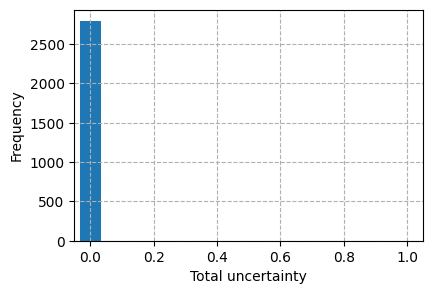

In [52]:
fig = rej.plot_uncertainty(unc_type="TU")